___

# Main Goal:
### Build and evaluate machine-learning models that classify text messages as spam or ham.

___

# Spam Message Detection Using Machine Learning

___

## 1. Project Overview

This project builds a machine-learning classifier that labels text messages as spam or ham.
The project compares multiple models, evaluates them using classification metrics,
analyzes common errors, and saves the best model for future predictions.

### Business / practical value

Spam filtering can reduce unwanted messages, scams, phishing attempts,
and time wasted by users. A good classifier should detect spam while avoiding
incorrectly marking legitimate messages as spam.

## 2. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load the Dataset

In [2]:
df = pd.read_csv("../data/SMSSpamCollection",
                sep="\t",
                header=None,
                names=["label", "message"])

In [3]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.shape

(5572, 2)

In [5]:
df.columns

Index(['label', 'message'], dtype='str')

In [6]:
df.dtypes

label      str
message    str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


___
The dataset contains one target column (`label`) and one text feature (`message`).
The target has two categories: spam and ham.
___

## 4. Data Understanding and Cleaning

In [8]:
df["label"].value_counts(normalize=True) * 100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

In [9]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(403)

___
Duplicate messages may represent repeated real-world spam campaigns.
However, exact duplicates can also cause overly optimistic evaluation if the same
message appears in both training and testing data.
___

In [11]:
df = df.drop_duplicates().reset_index(drop=True)

In [12]:
df.duplicated().sum(), df.shape

(np.int64(0), (5169, 2))

___
**Duplicates are removed to reduce leakage risk.**
___

In [13]:
label_map = {"ham": 0, "spam": 1}
df["target"] = df["label"].map(label_map)

In [14]:
df.head()

,label,message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [15]:
df.isna().sum()

label      0
message    0
target     0
dtype: int64

## 5. Exploratory Data Analysis

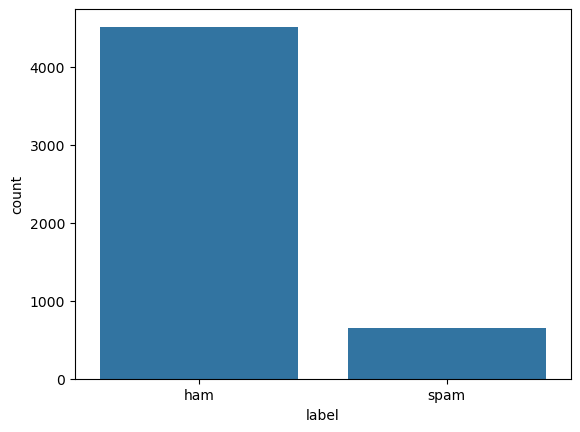

In [16]:
sns.countplot(x=df["label"])
plt.show;

___
The dataset has more ham messages than spam messages. Therefore, accuracy alone
is not enough: a model could achieve a high accuracy by predicting ham too often.
Precision, recall, and F1-score for the spam class are important.
___

In [17]:
df["message_length"] = df["message"].apply(len)
df["word_count"] = df["message"].apply(lambda x: len(x.split()))

In [18]:
df.head()

,label,message,target,message_length,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20
1,ham,Ok lar... Joking wif u oni...,0,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28
3,ham,U dun say so early hor... U c already then say...,0,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13


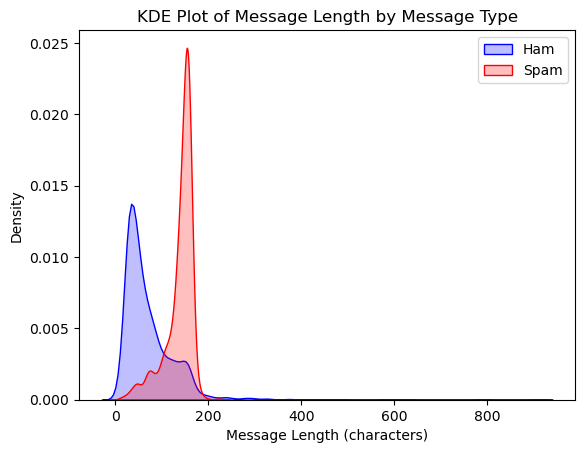

In [19]:
sns.kdeplot(df[df["label"]=="ham"]["message_length"], fill=True, color="blue", label="Ham")
sns.kdeplot(df[df["label"]=="spam"]["message_length"], fill=True, color="red", label="Spam")

plt.title("KDE Plot of Message Length by Message Type")
plt.xlabel("Message Length (characters)")
plt.ylabel("Density")
plt.legend()
plt.show()

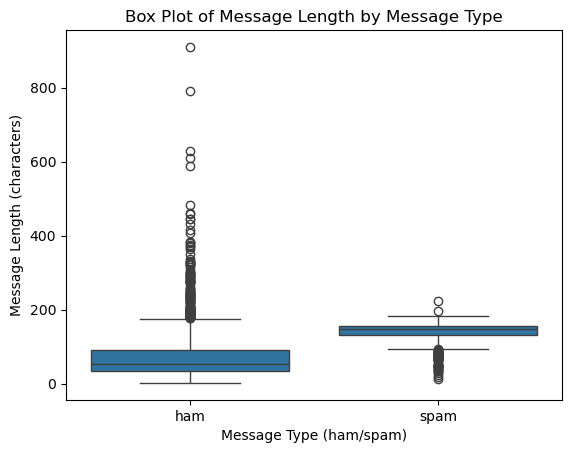

In [20]:
sns.boxplot(x="label",
            y="message_length",
            data=df)

plt.title("Box Plot of Message Length by Message Type")
plt.xlabel("Message Type (ham/spam)")
plt.ylabel("Message Length (characters)")
plt.show()

___
The plots show that spam messages have higher median length than ham, Ham messages often have extreme outliers, Spam has fewer but still some long outliers,
___

In [21]:
merged_string = df.groupby("label")["message"].agg(" ".join)
ham_string = merged_string["ham"]
spam_string = merged_string["spam"]

In [22]:
from wordcloud import WordCloud

ham_wordcloud = WordCloud(width=800,
                          height=400,
                          background_color="white").generate(ham_string)
spam_wordcloud = WordCloud(width=800,
                           height=400,
                           background_color="white").generate(spam_string)

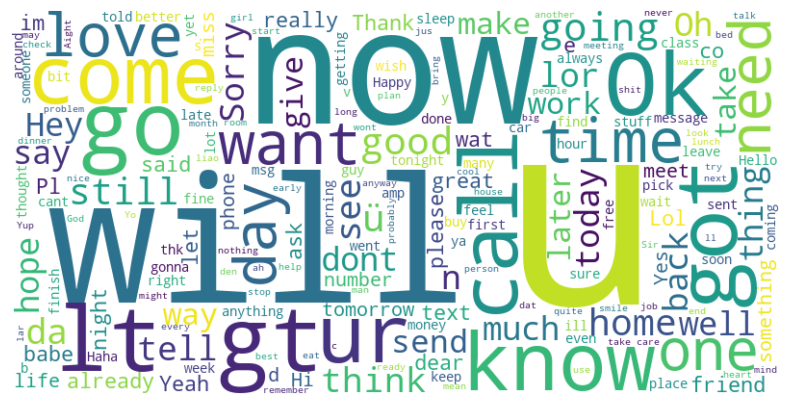

In [191]:
plt.figure(figsize=(10, 5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
# word-cloud for ham words

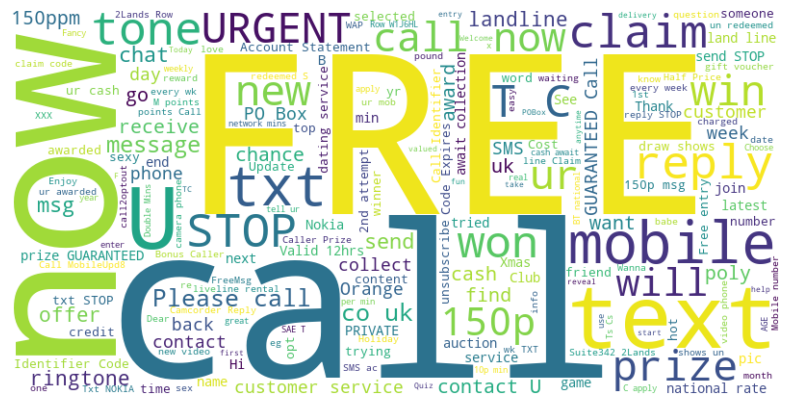

In [192]:
plt.figure(figsize=(10, 5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()
# word-cloud for spam words

## 6. Text Preprocessing

In [24]:
import re
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

In [25]:
STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', 'URL', text)
    text = re.sub(r'\d{10,}', 'PHONE', text)
    text = re.sub(r'[^\w\s!$]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [w for w in text.split() if w not in STOPWORDS]
    tagged_words = pos_tag(words)
    lemmatized = [lemmatizer.lemmatize(w, get_wordnet_pos(tag)) for w, tag in tagged_words]
    
    return " ".join(lemmatized)

In [26]:
df["cleaned_message"] = df["message"].apply(lambda x: clean_text(x))

In [27]:
df.sample(frac=1).head()

,label,message,target,message_length,word_count,cleaned_message
2468,ham,Erm. I thought the contract ran out the4th of ...,0,54,10,erm think contract run the4th october
1839,ham,Wah... Okie okie... Muz make use of e unlimite...,0,59,10,wah okie okie muz make use e unlimited haha
1517,ham,"The &lt;#&gt; g that i saw a few days ago, th...",0,143,29,ltgt g saw day ago guy want sell wifi ltgt 3g ...
771,ham,It does it on its own. Most of the time it fix...,0,117,24,time fix spell sometimes get completely diff w...
1853,ham,Is fujitsu s series lifebook good?,0,34,6,fujitsu series lifebook good


## 7. Train-Test Split

In [28]:
from sklearn.model_selection import train_test_split

X = df["cleaned_message"]
Y = df["target"]

In [29]:
X_train, X_test, Y_train, Y_test = train_test_split(X,
                                                    Y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=Y)

___
Stratification preserves the class distribution across training and test sets.
This is especially important because spam messages are less common than ham messages.
___

## 8. Baseline Model

In [30]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [31]:
model = Pipeline([
    ("vectorizer", CountVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])

model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.norm

In [32]:
model.score(X_test, Y_test)

0.9816247582205029

In [33]:
Y_pred = model.predict(X_test)

In [34]:
class_report = classification_report(Y_test, Y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       903
           1       0.94      0.91      0.93       131

    accuracy                           0.98      1034
   macro avg       0.97      0.95      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [35]:
conf_mat = confusion_matrix(Y_test, Y_pred)
print(conf_mat)

[[896   7]
 [ 12 119]]


In [36]:
pd.crosstab(Y_test,
            Y_pred,
            rownames=["True Label"],
            colnames=["Predicted Label"])

Predicted Label,0,1
True Label,,
0,896,7
1,12,119


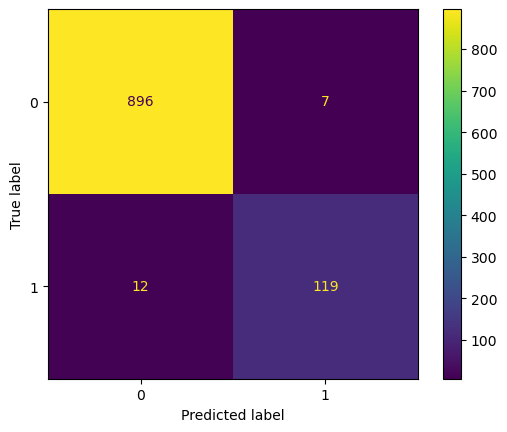

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(Y_test, Y_pred);

## 9. TF-IDF Feature Engineering

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [39]:
clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        min_df=5,
        max_df=0.9,
        stop_words="english",
        sublinear_tf=True,
    )),
    ("nb", MultinomialNB())
])

In [40]:
clf.fit(X_train, Y_train)
clf.score(X_test, Y_test)

0.9777562862669246

In [41]:
logreg = Pipeline([
    ("tfifg", TfidfVectorizer(
        min_df=5,
        max_df=0.9,
        stop_words="english",
        sublinear_tf=True
    )),
    ("logreg", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [42]:
logreg.fit(X_train, Y_train)
logreg.score(X_test, Y_test)

0.9709864603481625

In [43]:
svc = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("svc", LinearSVC())
])

In [44]:
svc.fit(X_train, Y_train)
svc.score(X_test, Y_test)

0.9835589941972921

## 10. Model Comparison

In [45]:
from sklearn.model_selection import KFold, cross_val_score

**Accuracy**

In [46]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [47]:
Count_NB_score = cross_val_score(model, X, Y, cv=kf, scoring="accuracy")
Count_NB_score

array([0.98259188, 0.98355899, 0.98549323, 0.98162476, 0.98257502])

In [48]:
Tfidf_NB_score = cross_val_score(clf, X, Y, cv=kf, scoring="accuracy")
Tfidf_NB_score

array([0.9787234 , 0.97969052, 0.97485493, 0.97678917, 0.97579864])

In [49]:
Tfidf_logreg_score = cross_val_score(logreg, X, Y, cv=kf, scoring="accuracy")
Tfidf_logreg_score

array([0.96808511, 0.97388781, 0.97775629, 0.97678917, 0.97870281])

In [50]:
Tfidf_svc_score = cross_val_score(svc, X, Y, cv=kf, scoring="accuracy")
Tfidf_svc_score

array([0.98065764, 0.98162476, 0.98259188, 0.98355899, 0.98354308])

**Classification Report**

In [51]:
# Prediction for each model
Y1_pred = model.predict(X_test)
Y2_pred = clf.predict(X_test)
Y3_pred = logreg.predict(X_test)
Y4_pred = svc.predict(X_test)

In [52]:
# Report for each model
Count_NB_report = classification_report(Y_test, Y1_pred, output_dict=True)
Tfidf_NB_report = classification_report(Y_test, Y2_pred, output_dict=True)
Tfidf_logred_report = classification_report(Y_test, Y3_pred, output_dict=True)
Tfidf_svc_report = classification_report(Y_test, Y4_pred, output_dict=True)

In [53]:
import pandas as pd

data = {
    "Count NB": [
        Count_NB_report["weighted avg"]["precision"],
        Count_NB_report["weighted avg"]["recall"],
        Count_NB_report["weighted avg"]["f1-score"]
    ],
    "Tfidf NB": [
        Tfidf_NB_report["weighted avg"]["precision"],
        Tfidf_NB_report["weighted avg"]["recall"],
        Tfidf_NB_report["weighted avg"]["f1-score"]
    ],
    "Tfidf logreg": [
        Tfidf_logred_report["weighted avg"]["precision"],
        Tfidf_logred_report["weighted avg"]["recall"],
        Tfidf_logred_report["weighted avg"]["f1-score"]
    ],
    "Tfidf SVC": [
        Tfidf_svc_report["weighted avg"]["precision"],
        Tfidf_svc_report["weighted avg"]["recall"],
        Tfidf_svc_report["weighted avg"]["f1-score"]
    ]
}

report_df = pd.DataFrame(data, index=["Precision","Recall","F1-score"])
report_df

,Count NB,Tfidf NB,Tfidf logreg,Tfidf SVC
Precision,0.981420,0.977847,0.971671,0.983456
Recall,0.981625,0.977756,0.970986,0.983559
F1-score,0.981471,0.977002,0.971263,0.983248


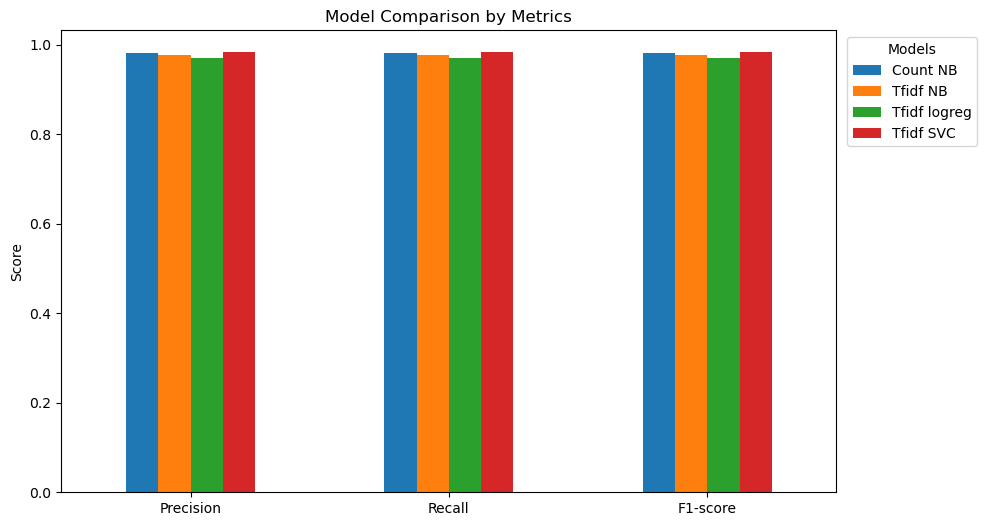

In [54]:
report_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison by Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Models", bbox_to_anchor=(1.005, 1), loc="upper left")
plt.show()

___
**After comparing the four models, the LinearSVC model(with TfidfVectorizer) is chosen as the final model.**
___

## 11. Model Evaluation(for the final model)

In [56]:
print(classification_report(Y_test, Y4_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       903
           1       0.97      0.89      0.93       131

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



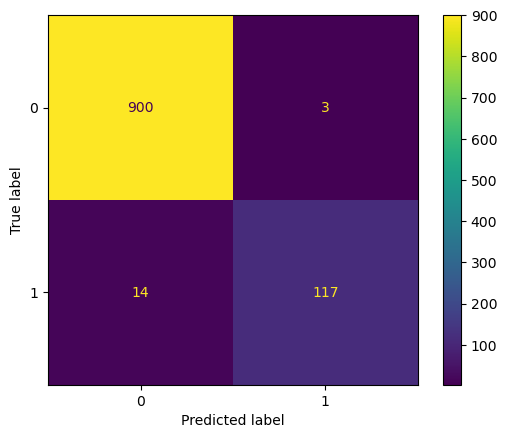

In [61]:
ConfusionMatrixDisplay.from_predictions(Y_test, Y4_pred);

## 12. Error Analysis

In [130]:
error_analysis_df = X_test.to_frame(name="Message")
error_analysis_df["Predicted_label"] = Y4_pred
error_analysis_df["Actual_label"] = Y_test
error_analysis_df["Correctness"] = error_analysis_df.apply(
    lambda row: "✅" if row["Predicted_label"] == row["Actual_label"] else "❌",
    axis=1
)

In [183]:
error_analysis_df.sample(frac=1).head()

,Message,Predicted_label,Actual_label,Correctness
3012,cinema plus drink appeal tomo fr thriller dire...,0,0,✅
3931,well general price ltgt oz let know ifwhenhow ...,0,0,✅
2358,cool ill text im way,0,0,✅
661,sm ac sun0819 post helloyou seem cool want say...,0,1,❌
2149,sicomo no!listened2the plaid albumquite gdthe ...,0,0,✅


## 13. Model Saving

In [184]:
import joblib

In [186]:
joblib.dump(svc, "../models/LinearSVC_TFIDF")

['../models/LinearSVC_TFIDF']

## 14. Limitations and Future Improvement

### Limitations
- The dataset may not represent current scam language.
- The classes are imbalanced.
- Text-only classification cannot detect all phishing attempts.
- A model trained on English messages may not work well for Amharic or other languages.

### Future Improvement
- Build a Streamlit web interface.